In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import read_config_utils as cu

import time

import sys
import os

from os.path import exists

In [3]:

#input_dir = 'output-files-bootstrap-test6b-4d-2a'

#input_dir = 'bootstrap-simple-pdf-toy-study6b-2d-v1b'

#input_dir = 'output-files-bootstrap-test6b-2d-2a-100k'

#input_dir = 'bootstrap-toy-study6b-2d-4c'
#input_dir = 'bootstrap-simple-pdf-toy-study6b-2d-4c'


#input_dir = 'freshtoys-toy-study6b-2d-4c'
#input_dir = 'freshtoys-simple-pdf-toy-study6b-2d-4c'

#input_dir = 'freshtoys-toy-study6b-2d-4c-save-model'
#input_dir = 'freshtoys-toy-study6b-2d-4c-save-model/freshmc-01'
#input_dir = 'freshtoys-toy-study6b-2d-4c-save-model/freshmc-02'


#input_dir = 'bootstrap-toy-study6b-1d-1a'



#input_dir = 'fit-pdf-toy-study-2d-1a'


#input_dir = 'bootstrap-toy-study8b-6d-1c'




#input_dir = 'bootstrap-toy-study8b-6d-2a-total-fluctuations'

#input_dir = 'bootstrap-toy-study8b-1d-2a-total-fluctuations'

#-------

#input_dir = 'hist-pdf-toy-study-1d-4e-reso-0.00'

#input_dir = 'hist-pdf-toy-study-1d-4e-reso-0.25'

#input_dir = 'hist-pdf-toy-study-1d-4e-reso-0.50'

#input_dir = 'hist-pdf-toy-study-1d-4e-reso-0.75'





#input_dir = 'hist-pdf-toy-study-1d-4f-reso-0.00'

#input_dir = 'hist-pdf-toy-study-1d-4f-reso-0.25'

#input_dir = 'hist-pdf-toy-study-1d-4f-reso-0.50'

#input_dir = 'hist-pdf-toy-study-1d-4f-reso-0.75'





#input_dir = 'bootstrap-toy-study9b-1d-1d-total-fluctuations'

#input_dir = 'bootstrap-toy-study9b-1d-1f-total-fluctuations'

#input_dir = 'bootstrap-toy-study9b-1d-1b-total-fluctuations'

#input_dir = 'bootstrap-toy-study9b-1d-1h-total-fluctuations'




#input_dir = 'bootstrap-all-in-one-inspect-of-1d-1a'

#input_dir = 'bootstrap-all-in-one-inspect-of-1d-1b'







#input_dir = 'bootstrap-all-in-one-inspect-of-1d-7a'

input_dir = 'bootstrap-ensemble-1d-1d'




ncalc = 1000
npoints = 1000

#-- 6 min
#ncalc = 1000
#npoints = 5000

#-- testing
#ncalc = 100
#npoints = 500


max_count = ncalc
if npoints > ncalc : max_count = npoints


In [4]:
with open('%s/train-and-true-samples.npy' % input_dir,'rb') as f :
    train_pts = np.load(f)
    train_det_pts = np.load(f)
    true_pts = np.load(f)
    true_det_pts = np.load(f)


In [5]:
train_pts.shape

(100000, 1)

In [6]:
config_file = '%s/config.txt' % (input_dir)

if not exists(config_file) :
    
    print("\n\n\n ******* Input file does not exist: %s\n\n\n" % config_file )
    sys.exit()

In [7]:
ndim = int(cu.get_par( config_file, "ndim"))
print("\n\n Number of feature dimensions: %d\n\n" % ndim)



 Number of feature dimensions: 1




## Check the particle and detector distributions

<function matplotlib.pyplot.show(close=None, block=None)>

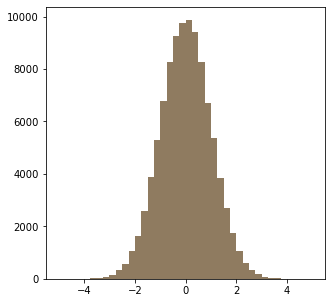

In [8]:
fig,ax = plt.subplots( 1, ndim, figsize=(5*ndim,5))

hbins=40
x0min=-5
x0max=5
x1min=-6
x1max=6

for fi in range(ndim) :
    
    if ndim > 1 :
        thisax = ax[fi]
    else :
        thisax = ax
        
    thisax.hist( train_pts[:,fi], bins=hbins, range=[x0min,x0max] )
    thisax.hist( train_det_pts[:,fi], bins=hbins, range=[x0min,x0max], alpha=0.5 )
    

plt.show

In [9]:
n_samples = 0

for fi in range(1000) :
    
    fname = '%s/bootstrap-weights-%03d.npy' % (input_dir, fi)
    
    if exists(fname) :
        n_samples = n_samples + 1
        
print("\n\n Found %d bootstrap samples.\n\n" % n_samples )



 Found 100 bootstrap samples.




## Load the weights for the first ncalc events from all of the bootstraps

In [10]:
#bootstrap_weights = np.zeros( shape = (n_samples, ncalc) )
bootstrap_weights = np.zeros( shape = (n_samples, max_count) )

In [11]:
for fi in range(n_samples) :
    
    fname = '%s/bootstrap-weights-%03d.npy' % (input_dir, fi)
    
    if exists(fname) :
        print( 'loading %s' % fname )
        with open(fname,'rb') as f :
            this_bootstrap_weights = np.load(f)
        #bootstrap_weights[fi,:] = this_bootstrap_weights[0:ncalc]
        bootstrap_weights[fi,:] = this_bootstrap_weights[0:max_count]
        
        
    else :
        print("\n\n *** file %s does not exist!\n\n" % fname )
        sys.exit()
        


loading bootstrap-ensemble-1d-1d/bootstrap-weights-000.npy
loading bootstrap-ensemble-1d-1d/bootstrap-weights-001.npy
loading bootstrap-ensemble-1d-1d/bootstrap-weights-002.npy
loading bootstrap-ensemble-1d-1d/bootstrap-weights-003.npy
loading bootstrap-ensemble-1d-1d/bootstrap-weights-004.npy
loading bootstrap-ensemble-1d-1d/bootstrap-weights-005.npy
loading bootstrap-ensemble-1d-1d/bootstrap-weights-006.npy
loading bootstrap-ensemble-1d-1d/bootstrap-weights-007.npy
loading bootstrap-ensemble-1d-1d/bootstrap-weights-008.npy
loading bootstrap-ensemble-1d-1d/bootstrap-weights-009.npy
loading bootstrap-ensemble-1d-1d/bootstrap-weights-010.npy
loading bootstrap-ensemble-1d-1d/bootstrap-weights-011.npy
loading bootstrap-ensemble-1d-1d/bootstrap-weights-012.npy
loading bootstrap-ensemble-1d-1d/bootstrap-weights-013.npy
loading bootstrap-ensemble-1d-1d/bootstrap-weights-014.npy
loading bootstrap-ensemble-1d-1d/bootstrap-weights-015.npy
loading bootstrap-ensemble-1d-1d/bootstrap-weights-016.n

In [12]:

corr_array = np.zeros( ncalc )
print(" ncalc = %d" % ncalc)

point_index = 57

for i in range(ncalc) :
    pair_cor = np.corrcoef( np.row_stack( (bootstrap_weights[:,point_index], bootstrap_weights[:,i]) ))
    corr_array[i] = pair_cor[0,1]


 ncalc = 1000


<function matplotlib.pyplot.show(close=None, block=None)>

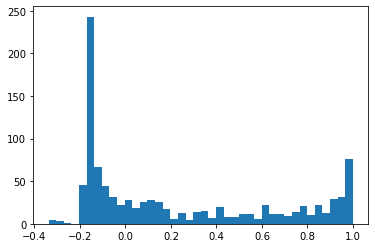

In [13]:
plt.hist( corr_array, bins=40)
plt.show

In [14]:
df0 = train_pts[:,0] - train_pts[point_index,0]
#df1 = train_pts[:,1] - train_pts[point_index,1]
#dr = np.sqrt( df0*df0 + df1*df1)
dr = np.abs(df0)

In [15]:
deltaf = train_pts[:,:] - train_pts[point_index,:]

In [16]:
deltaf.shape

(100000, 1)

In [17]:
df0.shape

(100000,)

In [18]:
dr2 = np.zeros( len(deltaf) )
for fi in range(0,ndim) :
    dr2 += deltaf[:,fi] * deltaf[:,fi]
dr = np.sqrt( dr2 )

<function matplotlib.pyplot.show(close=None, block=None)>

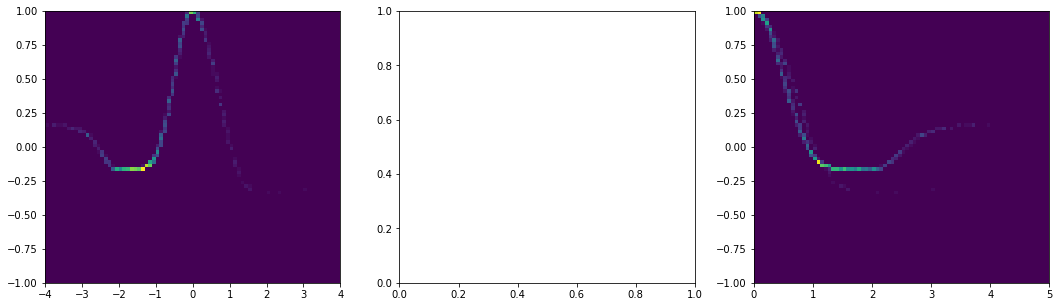

In [19]:
fig,ax = plt.subplots( 1, 3, figsize=(18,5))
ax[0].hist2d( df0[:ncalc], corr_array, bins=[80,80], range=([-4,4],[-1,1]))
#ax[1].hist2d( df1[:ncalc], corr_array, bins=[80,80], range=([-4,4],[-1,1]))
ax[2].hist2d( dr[:ncalc], corr_array, bins=[80,80], range=([0,5],[-1,1]))
plt.show

In [20]:
%%time



for point_index in range(npoints) :
    
    if (point_index % (npoints/10) == 0 ) :
        print(" Working on point %3d" % point_index)
        
    this_point_corr_array = np.zeros(ncalc)
    
    for i in range(ncalc) :
        #if i == point_index : continue
        pair_cor = np.corrcoef( np.row_stack( (bootstrap_weights[:,point_index], bootstrap_weights[:,i]) ))
        this_point_corr_array[i] = pair_cor[0,1]
    
    if point_index == 0 :
        all_points_df0 = train_pts[:ncalc,0] - train_pts[point_index,0]
        #all_points_df1 = train_pts[:ncalc,1] - train_pts[point_index,1]

        all_points_deltaf = train_pts[:ncalc,:] - train_pts[point_index,:]
        dr2 = np.zeros( len(all_points_deltaf) )
        for fi in range(0,ndim) :
            dr2 += all_points_deltaf[:,fi] * all_points_deltaf[:,fi]
        all_points_dr = np.sqrt( dr2 )
        all_points_corr_array = this_point_corr_array
        all_points_f0b = train_pts[:ncalc,0]
        #all_points_f1b = train_pts[:ncalc,1]
        all_points_coords = train_pts[:ncalc,:]
    else :
        this_point_df0 = train_pts[:ncalc,0] - train_pts[point_index,0]
        #this_point_df1 = train_pts[:ncalc,1] - train_pts[point_index,1] 

        this_point_deltaf = train_pts[:ncalc,:] - train_pts[point_index,:]
        dr2 = np.zeros( len(this_point_deltaf) )
        for fi in range(0,ndim) :
            dr2 += this_point_deltaf[:,fi] * this_point_deltaf[:,fi]
        all_points_dr = np.append( all_points_dr, np.sqrt( dr2 ) )       
        
        all_points_df0 = np.append( all_points_df0, this_point_df0 )
        #all_points_df1 = np.append( all_points_df1, this_point_df1 )
        all_points_corr_array = np.append(all_points_corr_array, this_point_corr_array)
        all_points_f0b = np.append(all_points_f0b, train_pts[:ncalc,0] )
        #all_points_f1b = np.append(all_points_f1b, train_pts[:ncalc,1] )
        all_points_coords = np.append( all_points_coords, train_pts[:ncalc,:], axis=0 )


 Working on point   0
 Working on point 100
 Working on point 200
 Working on point 300
 Working on point 400
 Working on point 500
 Working on point 600
 Working on point 700
 Working on point 800
 Working on point 900
CPU times: user 46.6 s, sys: 5.81 s, total: 52.4 s
Wall time: 52.4 s


In [21]:
all_points_corr_array.shape

(1000000,)

In [22]:
all_points_df0.shape

(1000000,)

<function matplotlib.pyplot.show(close=None, block=None)>

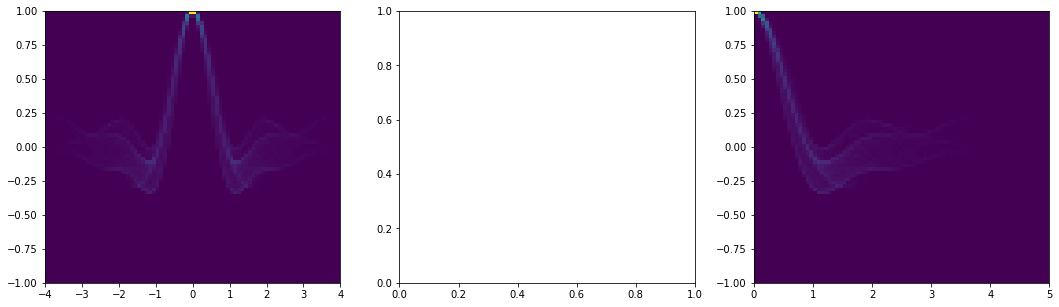

In [23]:
fig,ax = plt.subplots( 1, 3, figsize=(18,5))
ax[0].hist2d( all_points_df0, all_points_corr_array, bins=[80,80], range=([-4,4],[-1,1]))
#ax[1].hist2d( all_points_df1, all_points_corr_array, bins=[80,80], range=([-4,4],[-1,1]))
ax[2].hist2d( all_points_dr, all_points_corr_array, bins=[80,80], range=([0,5],[-1,1]))

#plt.savefig('plots/correlation-vs-distance-%s.png' % sample_name, bbox_inches='tight')
#plt.savefig('plots/correlation-vs-distance-%s.pdf' % sample_name, bbox_inches='tight')

plt.show

In [24]:
#plt.hist2d( all_points_f0b, all_points_f1b, bins=[80,80] )
#plt.show

In [25]:
#plt.hist2d( all_points_f0b[all_points_corr_array>0.8], all_points_f1b[all_points_corr_array>0.8], bins=[80,80] )
#plt.show

## Save the output

In [26]:
with open( '%s/correlations.npy' % input_dir, 'wb') as f :
    np.save(f, all_points_df0)
    #np.save(f, all_points_df1)
    np.save(f, all_points_dr)
    np.save(f, all_points_corr_array)
    

In [27]:
with open( '%s/correlation-points-feature-coords.npy' % input_dir, 'wb') as f :
    np.save(f, all_points_f0b)
    #np.save(f, all_points_f1b)
    np.save(f, all_points_coords)

In [28]:
all_points_f0b.shape

(1000000,)

In [29]:
all_points_coords.shape

(1000000, 1)

In [30]:
train_pts[:ncalc,:].shape

(1000, 1)

In [31]:
a1 = train_pts[:ncalc,:]

In [32]:
a1.shape

(1000, 1)

In [33]:
all_points_corr_array.shape

(1000000,)

In [34]:
a2 = np.append(a1, train_pts[:ncalc,:], axis=0 )

In [35]:
a2.shape

(2000, 1)

In [36]:
def profile2d( axis, xvals, yvals, hbins, hrange, drawhist=True, drawline=True ) :
    
    hist_data = axis.hist2d( xvals, yvals, bins=hbins, range=hrange)
    
    if not drawhist :
        ax.cla()

    nybins = len(hist_data[0][0])
    print("number of y bins: %d" % nybins)

    nxbins = len(hist_data[0])
    print("number of x bins: %d" % nxbins)



    x_vals = np.zeros( nxbins )
    avey_vals = np.zeros( nxbins )
    rmsy_vals = np.zeros( nxbins )

    for xbi in range( nxbins ) :

        wsum = 0
        ywsum = 0
        yywsum = 0

        xval = 0.5 * ( hist_data[1][xbi] + hist_data[1][xbi+1] )
        #print(" xbin %d has center at %6.3f" % ( xbin_ind, xval ))

        for ybi in range( nybins ) :  
            yval = 0.5 * ( hist_data[2][ybi] + hist_data[2][ybi+1] )
            bin_content = hist_data[0][xbi][ybi]
            wsum = wsum + bin_content
            ywsum = ywsum + yval * bin_content
            yywsum = yywsum + yval * yval * bin_content
            #print("  %3d : y = %6.3f  bin content = %7d" % (bi, yval, bin_content))

        ave_y = ywsum / wsum
        ave_yy = yywsum / wsum
        rms_y = ave_yy - ave_y * ave_y
        #print(" Ave y = %.3f, RMS y = %.3f" % ( ave_y, rms_y) )

        x_vals[xbi] = xval
        avey_vals[xbi] = ave_y
        rmsy_vals[xbi] = rms_y


    #for xbi in range( nxbins ) :
        #print("  %4d :  x = %7.3f   ave y = %7.3f  rms y = %7.3f" % ( xbi, x_vals[xbi], avey_vals[xbi], rmsy_vals[xbi]))

    if drawline :
        ax.plot( (hist_data[1][0], hist_data[1][-1]), (0,0) )  
    
    ax.errorbar( x_vals, avey_vals, yerr=rmsy_vals, fmt='-o')
    
    plt.show
    
    return x_vals, avey_vals, rmsy_vals
    

number of y bins: 80
number of x bins: 80


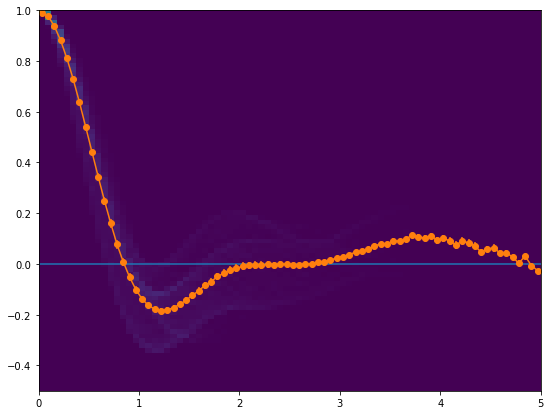

In [37]:
fig,ax = plt.subplots(1,1,figsize=(9,7))

a,b,c = profile2d( ax, all_points_dr, all_points_corr_array, hbins=[80,80], hrange=([0,5],[-0.5,1]), drawhist=True)